# Jev vs GPT: classifying 77 banking intents

[TypeSafe](https://docs.typesafe.ai/api) exposes one evaluation endpoint, `POST /v1/systemone`.
You send it some content plus a **typed question**, and it answers in that type - no parsing
free text. `jev-latest` is the model behind it.

This notebook puts that against OpenAI on a genuinely hard classification task: 77
fine-grained banking support intents, many of them easy to confuse (`declined_transfer` vs
`declined_card_payment`, `card_arrival` vs `card_delivery_estimate`).

We use the **official HuggingFace split**: 3,080 held-out test rows, sampled down to 1,000.
All 77 intents appear in the sample (7-19 rows each).

> **A note on the older numbers in this repo.** `prompt_optimisation_gepa_ace` reports Claude
> Haiku 4.5 baselines of 79.7% (chain-of-thought), 76.1% (GEPA) and 71.6% (ACE). Those were
> measured on a 201-row subset that - as it turns out - was drawn entirely from the banking77
> **train** split, not the test split. It shares zero rows with the sample used here, so those
> figures are not comparable to this run and are deliberately left off the chart.

### Making it a fair fight

Both models get the **same instruction string** and the **same bare list of label names** -
no hand-written descriptions for either side. Both are **format-constrained**: Jev through
its `choice` type, OpenAI through a JSON-schema `enum`. Neither can return an answer outside
the label set, so whatever gap appears is about judgement, not about following instructions.
Both are zero-shot.

## 1. Setup

In [1]:
# !pip install requests openai pandas matplotlib tqdm

In [2]:
import collections
import hashlib
import json
import math
import os
import time
from concurrent.futures import ThreadPoolExecutor

import matplotlib.pyplot as plt
import pandas as pd
import pyarrow.parquet as pq
import requests
from openai import OpenAI
from tqdm.auto import tqdm

/Users/marie/Documents/github/miptgirl_medium/jev/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Keys live in `config.json` outside the repo, so nothing secret is ever committed.

In [3]:
with open("../../config.json") as f:
    config = json.load(f)

JEV_API_KEY = config["JEV_API_KEY"]
openai_client = OpenAI(api_key=config["OPENAI_API_KEY"])

## 2. The data

The parquet files store the label as an integer 0-76. The human-readable intent names ride
along in the file's HuggingFace metadata, so we can decode them without a lookup table.

In [4]:
DATASET = "banking77"
TEST_FILE = "data/banking77_test.parquet"
SAMPLE_SIZE = 1000

test_df = pd.read_parquet(TEST_FILE)

# the intent names are stored in the parquet metadata, not in the data itself
meta = json.loads(pq.ParquetFile(TEST_FILE).schema_arrow.metadata[b"huggingface"])
LABELS = meta["info"]["features"]["label"]["names"]

data = test_df.sample(n=SAMPLE_SIZE, random_state=42).reset_index(drop=True)
data["gold"] = data["label"].map(lambda i: LABELS[i])

print(f"test split     : {len(test_df)} rows")
print(f"sampled        : {len(data)} rows")
print(f"labels offered : {len(LABELS)}")
print(f"labels present : {data['gold'].nunique()}")
data[["text", "gold"]].head()

test split     : 3080 rows
sampled        : 1000 rows
labels offered : 77
labels present : 77


,text,gold
0,How do I link this new card?,card_linking
1,How do I retrieve my card from the machine?,card_swallowed
2,I want to know where the funds come from.,verify_source_of_funds
3,"I just activated auto top-up, but it is not le...",automatic_top_up
4,Why did I have to pay extra because I paid wit...,card_payment_fee_charged


Each row gets an id derived from its **text**, not its position. That matters for the cache:
if the key were the row number, changing `SAMPLE_SIZE` would quietly reuse an answer computed
for a completely different message.

In [5]:
data["record_id"] = data["text"].map(
    lambda text: hashlib.md5(text.encode()).hexdigest()[:12]
)

INSTRUCTIONS = (
    "Classify this banking customer support message into its intent category. "
    "Choose the single category that best matches what the customer is asking about."
)

records = data[["record_id", "text", "gold"]].to_dict(orient="records")
print(f"{len(records)} records ready")

1000 records ready


## 3. One Jev call

This is the whole API. `state` is the content, `questions` is a map of typed questions, and a
`choice` question takes its options as the `criteria` map. Descriptions are optional - we pass
`None` so the model sees nothing but the label names, exactly like the OpenAI side.

The answer comes back as the chosen key plus a **confidence**, which is the part you do not get
from a plain chat completion.

In [6]:
JEV_URL = "https://api.typesafe.ai/v1/systemone"


def call_jev(text, labels, instructions, model="jev-latest"):
    """Ask Jev to pick exactly one label."""
    response = requests.post(
        JEV_URL,
        headers={"Authorization": f"Bearer {JEV_API_KEY}"},
        json={
            "state": text,
            "model": model,
            "questions": {
                "label": {
                    "type": "choice",
                    "instructions": instructions,
                    "criteria": {label: None for label in labels},
                }
            },
        },
        timeout=60,
    )
    response.raise_for_status()
    body = response.json()
    answer = body["answers"]["label"]
    return {
        "label": answer["choice"],
        "confidence": answer.get("confidence"),
        "input_tokens": body["usage"]["input_tokens"],
        "output_tokens": body["usage"]["output_tokens"],
    }

In [7]:
example = records[0]
jev_answer = call_jev(example["text"], LABELS, INSTRUCTIONS)

print("text      :", example["text"])
print("gold      :", example["gold"])
print("jev       :", jev_answer)

text      : How do I link this new card?
gold      : card_linking
jev       : {'label': 'card_linking', 'confidence': 1.0, 'input_tokens': 1036, 'output_tokens': 827}


## 4. The same question to OpenAI

To keep it a fair comparison the answer has to be pinned to the same label set, which is what
the JSON schema `enum` does - the model cannot invent a category or wrap it in a sentence.

Note what is missing: **no confidence**. OpenAI returns the label and nothing else. You can
approximate one from token logprobs, but it is not the calibrated number Jev hands you, and
some models refuse logprobs outright (`gpt-5-mini` returns a 403).

In [8]:
def call_openai(text, labels, instructions, model):
    """Ask an OpenAI model the same question, constrained to the same labels."""
    response = openai_client.chat.completions.create(
        model=model,
        messages=[
            {"role": "system", "content": instructions},
            {"role": "user", "content": text},
        ],
        response_format={
            "type": "json_schema",
            "json_schema": {
                "name": "classification",
                "strict": True,
                "schema": {
                    "type": "object",
                    "properties": {"label": {"type": "string", "enum": labels}},
                    "required": ["label"],
                    "additionalProperties": False,
                },
            },
        },
        timeout=60,
    )
    return {
        "label": json.loads(response.choices[0].message.content)["label"],
        "confidence": None,  # OpenAI does not give us one
        "input_tokens": response.usage.prompt_tokens,
        "output_tokens": response.usage.completion_tokens,
    }

## 5. Caching

A plain dict saved to one JSON file, keyed `"<model>|<record_id>"`. Two rules make it useful:

1. **Only successful answers are cached.** A failed call is never stored, so re-running a cell
   retries exactly the rows that failed and skips everything that already worked.
2. **The key includes the model**, so adding a model does not re-run the ones already done.

In [9]:
CACHE_FILE = f"cache/{DATASET}.json"


def load_cache():
    if os.path.exists(CACHE_FILE):
        with open(CACHE_FILE) as f:
            return json.load(f)
    return {}


def save_cache(cache):
    os.makedirs("cache", exist_ok=True)
    with open(CACHE_FILE, "w") as f:
        json.dump(cache, f, indent=1)


cache = load_cache()
print(f"{len(cache)} answers already cached")

3603 answers already cached


The runner is the only slightly fiddly piece, and only because of two real-world facts: calls
sometimes fail transiently (the TypeSafe API returns a `503` when the model is briefly
unavailable), and running 200+ calls one at a time is slow.

In [10]:
def run_model(model_name, call, records, workers=8):
    """Classify every record with one model, skipping whatever is already cached."""

    def classify(record):
        key = f"{model_name}|{record['record_id']}"
        for attempt in range(3):
            try:
                return key, call(record["text"]), None
            except Exception as error:
                message = str(error)
                # a spent account will not recover on a retry
                if "no credits" in message or "insufficient_quota" in message:
                    return key, None, message[:120]
                if attempt == 2:
                    return key, None, message[:120]
                time.sleep(2**attempt)

    todo = [r for r in records if f"{model_name}|{r['record_id']}" not in cache]
    print(f"{model_name}: {len(records) - len(todo)} cached, {len(todo)} to call")

    failures = []
    with ThreadPoolExecutor(max_workers=workers) as pool:
        for key, answer, error in tqdm(pool.map(classify, todo), total=len(todo)):
            if error:
                failures.append(error)
            else:
                cache[key] = answer
    save_cache(cache)

    if failures:
        print(f"  {len(failures)} calls failed, e.g. {failures[0]}")
        print("  re-run this cell to retry just those")

    # stitch the cached answers back onto the records
    return [
        {"record_id": r["record_id"], "gold": r["gold"], **cache[f"{model_name}|{r['record_id']}"]}
        for r in records
        if f"{model_name}|{r['record_id']}" in cache
    ]

## 6. Run every model

One entry per model. Adding another is one line.

In [11]:
MODELS = {
    "jev-latest": lambda text: call_jev(text, LABELS, INSTRUCTIONS),
    "gpt-5.6-luna": lambda text: call_openai(text, LABELS, INSTRUCTIONS, "gpt-5.6-luna"),
    "gpt-5.6-terra": lambda text: call_openai(text, LABELS, INSTRUCTIONS, "gpt-5.6-terra"),
}

results = {}
for model_name, call in MODELS.items():
    results[model_name] = run_model(model_name, call, records)

jev-latest: 1000 cached, 0 to call


0it [00:00, ?it/s]

0it [00:00, ?it/s]

gpt-5.6-luna: 1000 cached, 0 to call


0it [00:00, ?it/s]

0it [00:00, ?it/s]

gpt-5.6-terra: 1000 cached, 0 to call


0it [00:00, ?it/s]

0it [00:00, ?it/s]

## 7. Scoring

Both models answer with a key from `LABELS`, so scoring is a plain string comparison.

The confidence interval matters more than it looks. On a couple of hundred rows the sampling
error is several points wide - usually wider than the gap people try to read between two
models. Quoting accuracy without it is how benchmarks end up overclaiming.

In [12]:
def wilson_interval(correct, total, z=1.96):
    """95% confidence interval for an accuracy figure."""
    if total == 0:
        return 0.0, 0.0
    p = correct / total
    denominator = 1 + z**2 / total
    centre = (p + z**2 / (2 * total)) / denominator
    margin = z * math.sqrt(p * (1 - p) / total + z**2 / (4 * total**2)) / denominator
    return round(max(0, centre - margin), 4), round(min(1, centre + margin), 4)


rows = []
for model_name, answers in results.items():
    if not answers:
        print(f"{model_name}: no answers at all - skipped")
        continue
    correct = sum(a["label"] == a["gold"] for a in answers)
    low, high = wilson_interval(correct, len(answers))
    rows.append(
        {
            "model": model_name,
            "answered": len(answers),
            "correct": correct,
            "accuracy": round(correct / len(answers), 4),
            "ci_low": low,
            "ci_high": high,
            "input_tokens": sum(a["input_tokens"] or 0 for a in answers),
            "output_tokens": sum(a["output_tokens"] or 0 for a in answers),
        }
    )

scores = pd.DataFrame(rows).sort_values("accuracy", ascending=False).reset_index(drop=True)
scores

,model,answered,correct,accuracy,ci_low,ci_high,input_tokens,output_tokens
0,gpt-5.6-luna,1000,862,0.862,0.8392,0.8820,474552,44261
1,gpt-5.6-terra,1000,839,0.839,0.8149,0.8605,474552,21562
2,jev-latest,1000,790,0.790,0.7637,0.8141,1040811,828290


> If a model answered far fewer rows than the others, its accuracy is measured on a different
> (and easier or harder) subset - check `answered` before comparing the numbers.

## 8. The comparison

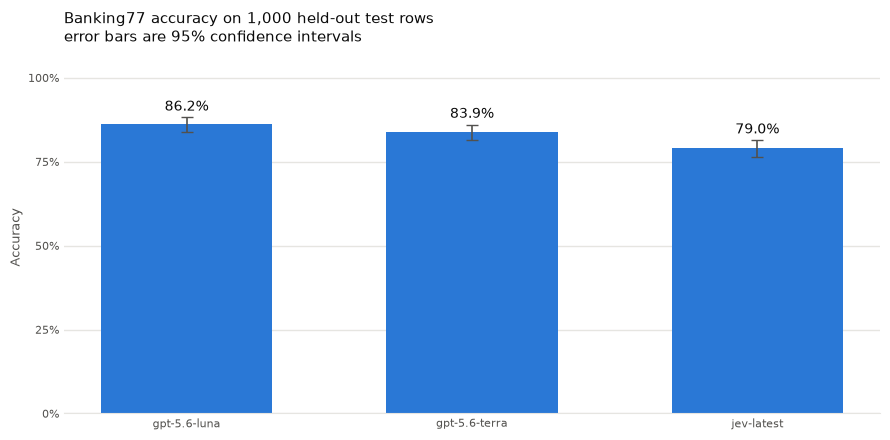

In [13]:
plot_df = scores[["model", "accuracy", "ci_low", "ci_high"]].copy()
plot_df["is_baseline"] = False

fig, ax = plt.subplots(figsize=(9, 4.5))

colors = ["#9a9992" if b else "#2a78d6" for b in plot_df["is_baseline"]]
errors = [plot_df["accuracy"] - plot_df["ci_low"], plot_df["ci_high"] - plot_df["accuracy"]]

ax.bar(
    plot_df["model"], plot_df["accuracy"], color=colors, width=0.6,
    yerr=errors, capsize=4, error_kw={"ecolor": "#52514e", "elinewidth": 1.2},
)

# label above the error bar cap so the two do not overlap
for x, (value, high) in enumerate(zip(plot_df["accuracy"], plot_df["ci_high"])):
    ax.text(x, high + 0.02, f"{value:.1%}", ha="center", color="#0b0b0b", fontsize=10)

ax.set_ylim(0, 1.05)
ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(["0%", "25%", "50%", "75%", "100%"])
ax.set_ylabel("Accuracy", color="#52514e", fontsize=9)
ax.yaxis.grid(True, color="#e6e5e1", linewidth=1)
ax.set_axisbelow(True)
ax.tick_params(colors="#52514e", labelsize=8, length=0)
for side in ("top", "right", "left"):
    ax.spines[side].set_visible(False)
ax.spines["bottom"].set_color("#e6e5e1")
ax.set_title(
    "Banking77 accuracy on 1,000 held-out test rows\n"
    "error bars are 95% confidence intervals",
    color="#0b0b0b", fontsize=11, loc="left", pad=14,
)
fig.tight_layout()
plt.show()

## 9. How fast is each API?

The accuracy run above is threaded and cached, so its wall-clock time says nothing about how
fast a single call is. To measure that we call the APIs directly - **bypassing the cache**, and
**one call at a time**, because eight concurrent workers measure throughput, not latency.

These are small samples over a network, so treat them as an order of magnitude rather than a
precise figure.

In [14]:
SPEED_SAMPLE = 20

speed_rows = []
for model_name, call in MODELS.items():
    latencies = []
    for record in tqdm(records[:SPEED_SAMPLE], desc=model_name):
        start = time.perf_counter()
        try:
            call(record["text"])  # deliberately uncached - we are timing the API itself
            latencies.append(time.perf_counter() - start)
        except Exception as error:
            print(f"  {model_name} failed: {str(error)[:100]}")

    if not latencies:
        continue

    latencies.sort()
    speed_rows.append(
        {
            "model": model_name,
            "calls": len(latencies),
            "mean_s": round(sum(latencies) / len(latencies), 2),
            "median_s": round(latencies[len(latencies) // 2], 2),
            "p90_s": round(latencies[int(len(latencies) * 0.9)], 2),
            "min_s": round(latencies[0], 2),
            "max_s": round(latencies[-1], 2),
        }
    )

speed = pd.DataFrame(speed_rows).sort_values("median_s").reset_index(drop=True)
speed

jev-latest:   0%|          | 0/20 [00:00<?, ?it/s]

jev-latest:   5%|▌         | 1/20 [00:00<00:13,  1.43it/s]

jev-latest:  10%|█         | 2/20 [00:01<00:12,  1.43it/s]

jev-latest:  15%|█▌        | 3/20 [00:02<00:11,  1.44it/s]

jev-latest:  20%|██        | 4/20 [00:02<00:11,  1.43it/s]

...

gpt-5.6-terra:  90%|█████████ | 18/20 [01:29<00:04,  2.08s/it]

gpt-5.6-terra:  95%|█████████▌| 19/20 [01:31<00:02,  2.21s/it]

gpt-5.6-terra: 100%|██████████| 20/20 [01:33<00:00,  1.93s/it]

gpt-5.6-terra: 100%|██████████| 20/20 [01:33<00:00,  4.66s/it]

,model,calls,mean_s,median_s,p90_s,min_s,max_s
0,jev-latest,20,0.71,0.69,0.78,0.59,1.25
1,gpt-5.6-luna,20,0.97,0.91,1.32,0.60,2.02
2,gpt-5.6-terra,20,4.65,2.48,15.97,0.75,35.93


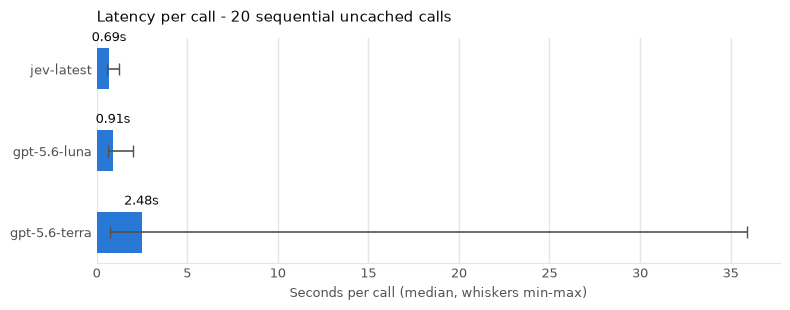

In [15]:
if not speed.empty:
    fig, ax = plt.subplots(figsize=(8, 3.2))

    y = range(len(speed))
    left = speed["median_s"] - speed["min_s"]
    right = speed["max_s"] - speed["median_s"]

    ax.barh(
        y, speed["median_s"], color="#2a78d6", height=0.5,
        xerr=[left, right], capsize=4,
        error_kw={"ecolor": "#52514e", "elinewidth": 1.2},
    )

    for yi, value in zip(y, speed["median_s"]):
        ax.text(value, yi - 0.34, f"{value:.2f}s", ha="center", color="#0b0b0b", fontsize=9)

    ax.set_yticks(list(y))
    ax.set_yticklabels(speed["model"], fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel("Seconds per call (median, whiskers min-max)", color="#52514e", fontsize=9)
    ax.xaxis.grid(True, color="#e6e5e1", linewidth=1)
    ax.set_axisbelow(True)
    ax.tick_params(colors="#52514e", labelsize=9, length=0)
    for side in ("top", "right", "left"):
        ax.spines[side].set_visible(False)
    ax.spines["bottom"].set_color("#e6e5e1")
    ax.set_title(
        f"Latency per call - {SPEED_SAMPLE} sequential uncached calls",
        color="#0b0b0b", fontsize=11, loc="left", pad=12,
    )
    fig.tight_layout()
    plt.show()

## 10. Where the errors are

With 77 intents the headline number matters less than *which* pairs get confused.
A model that mixes up two genuinely adjacent categories is failing differently from one
that picks something unrelated.

In [16]:
for model_name, answers in results.items():
    if not answers:
        continue
    mistakes = [a for a in answers if a["label"] != a["gold"]]
    print(f"\n=== {model_name}: {len(mistakes)} mistakes out of {len(answers)} ===")
    confusions = collections.Counter((a["gold"], a["label"]) for a in mistakes)
    for (gold, predicted), count in confusions.most_common(10):
        print(f"  {count}x  {gold}  ->  {predicted}")


=== jev-latest: 210 mistakes out of 1000 ===
  14x  order_physical_card  ->  get_physical_card
  9x  get_physical_card  ->  change_pin
  6x  top_up_by_bank_transfer_charge  ->  receiving_money
  5x  reverted_card_payment?  ->  declined_card_payment
  5x  balance_not_updated_after_bank_transfer  ->  pending_transfer
  4x  card_payment_not_recognised  ->  compromised_card
  4x  top_up_by_bank_transfer_charge  ->  transfer_into_account
  4x  balance_not_updated_after_bank_transfer  ->  transfer_timing
  4x  beneficiary_not_allowed  ->  failed_transfer
  4x  why_verify_identity  ->  unable_to_verify_identity

=== gpt-5.6-luna: 138 mistakes out of 1000 ===
  12x  get_physical_card  ->  change_pin
  6x  compromised_card  ->  card_payment_not_recognised
  6x  top_up_by_bank_transfer_charge  ->  receiving_money
  4x  order_physical_card  ->  get_physical_card
  3x  order_physical_card  ->  card_arrival
  3x  topping_up_by_card  ->  pending_top_up
  3x  top_up_by_bank_transfer_charge  ->  tran

## 11. Is the confidence worth anything?

This is the part you cannot do with a plain chat completion. If accuracy climbs with
confidence, you can route the low-confidence tail to a human and leave the rest alone - which
is usually the whole reason to run a classifier at all.

In [17]:
confident = [
    {**a, "model": name}
    for name, answers in results.items()
    for a in answers
    if a.get("confidence") is not None
]

if not confident:
    print("No model returned a confidence.")
else:
    frame = pd.DataFrame(confident)
    frame["correct"] = frame["label"] == frame["gold"]
    frame["bucket"] = pd.cut(
        frame["confidence"], [0, 0.5, 0.7, 0.9, 1.0], include_lowest=True,
        labels=["<=0.5", "0.5-0.7", "0.7-0.9", "0.9-1.0"],
    )
    calibration = (
        frame.groupby(["model", "bucket"], observed=False)["correct"]
        .agg(["mean", "size"])
        .reset_index()
    )
    display(calibration)

,model,bucket,mean,size
0,jev-latest,<=0.5,0.350000,60
1,jev-latest,0.5-0.7,0.452830,106
2,jev-latest,0.7-0.9,0.619048,189
3,jev-latest,0.9-1.0,0.936434,645


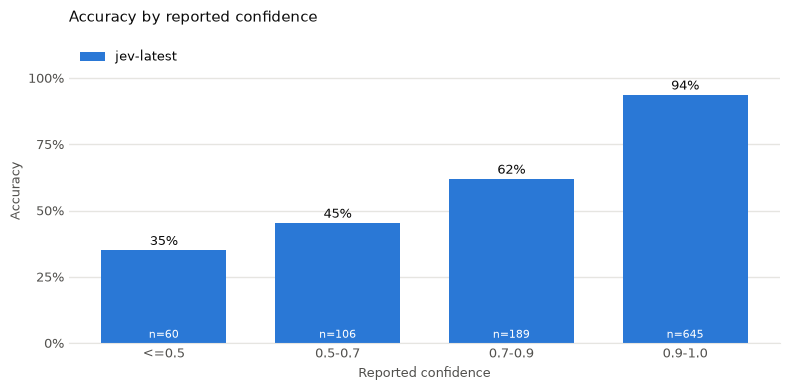

In [18]:
if confident:
    fig, ax = plt.subplots(figsize=(8, 4))
    buckets = ["<=0.5", "0.5-0.7", "0.7-0.9", "0.9-1.0"]
    models = calibration["model"].unique()
    width = 0.8 / len(models)

    for i, model_name in enumerate(models):
        subset = calibration[calibration["model"] == model_name].set_index("bucket")
        subset = subset.reindex(buckets)
        positions = [b + i * width for b in range(len(buckets))]
        ax.bar(
            positions, subset["mean"].fillna(0), width=width * 0.9,
            color=["#2a78d6", "#eb6834", "#1baf7a"][i % 3], label=model_name,
        )
        for position, value, size in zip(positions, subset["mean"], subset["size"].fillna(0)):
            if size:
                ax.text(position, value + 0.02, f"{value:.0%}", ha="center",
                        color="#0b0b0b", fontsize=9)
                ax.text(position, 0.02, f"n={int(size)}", ha="center",
                        color="#ffffff", fontsize=8)

    ax.set_xticks([b + width * (len(models) - 1) / 2 for b in range(len(buckets))])
    ax.set_xticklabels(buckets)
    ax.set_xlabel("Reported confidence", color="#52514e", fontsize=9)
    ax.set_ylabel("Accuracy", color="#52514e", fontsize=9)
    ax.set_ylim(0, 1.15)
    ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(["0%", "25%", "50%", "75%", "100%"])
    ax.yaxis.grid(True, color="#e6e5e1", linewidth=1)
    ax.set_axisbelow(True)
    ax.tick_params(colors="#52514e", labelsize=9, length=0)
    for side in ("top", "right", "left"):
        ax.spines[side].set_visible(False)
    ax.spines["bottom"].set_color("#e6e5e1")
    ax.legend(frameon=False, fontsize=9, loc="upper left", ncol=3)
    ax.set_title("Accuracy by reported confidence", color="#0b0b0b",
                 fontsize=11, loc="left", pad=12)
    fig.tight_layout()
    plt.show()

## 12. Save the per-row results

In [19]:
os.makedirs("results", exist_ok=True)

if results:
    flat = pd.DataFrame(
        [{**a, "model": name} for name, answers in results.items() for a in answers]
    )
    flat.to_csv(f"results/{DATASET}_predictions.csv", index=False)
    scores.to_csv(f"results/{DATASET}_summary.csv", index=False)
    print(f"wrote results/{DATASET}_predictions.csv ({len(flat)} rows)")

wrote results/banking77_predictions.csv (3000 rows)


## Notes

- **Overlapping intervals mean "not distinguishable".** If two bars sit a couple of points
  apart with overlapping error bars, the honest conclusion is that this sample cannot tell
  them apart. The fix is more rows, not a bolder claim - and at 1,000 rows the interval is
  roughly half as wide as it was at 201.
- **The older repo baselines are not comparable.** They were scored on 201 rows taken from
  the banking77 *train* split, with a different harness (DSPy, exact-match lowercase). This
  notebook uses the official held-out test split, which shares none of those rows.
- **To raise the sample**, change `SAMPLE_SIZE` and re-run. Because the cache key is a hash
  of the text, the rows you already paid for are reused and only the new ones are called.
- **Token cost has a different shape per API.** Jev returns a probability over every option, so
  its output tokens scale with the size of the label set. OpenAI under an enum emits just the
  chosen label. Compare cost per correct answer, not raw token counts.
- **Only Jev returns a confidence.** That is the practical difference between the two APIs for
  this kind of task.
- **Latency and throughput are different questions.** The speed section times single sequential
  calls; the accuracy run uses eight workers, so its wall-clock time reflects concurrency, not
  per-call speed. Which one matters depends on whether you are classifying one item live or a
  million overnight.